# SAL 603 – Final Project: MLB Team Stats vs Win% (2021–2025)
**Research Question:** Which team statistics (batting, pitching, fielding) are most correlated with win percentage in MLB?

**Data Sources:** FanGraphs via pybaseball (`team_batting`, `team_pitching`); W/L records hardcoded from Baseball-Reference final standings  
**Group Members:** Shaelyn Rix, Jacob Van Duynhoven, Zach Spaulding, Zach Foster

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Hardcoded W/L records 2021–2025 (Baseball-Reference final standings) ──────
import pandas as pd

wl_data = [
    (2021,'Arizona Diamondbacks',52,110),(2021,'Atlanta Braves',88,73),
    (2021,'Baltimore Orioles',52,110),(2021,'Boston Red Sox',92,70),
    (2021,'Chicago Cubs',71,91),(2021,'Chicago White Sox',93,69),
    (2021,'Cincinnati Reds',83,79),(2021,'Cleveland Guardians',80,82),
    (2021,'Colorado Rockies',74,87),(2021,'Detroit Tigers',77,85),
    (2021,'Houston Astros',95,67),(2021,'Kansas City Royals',74,88),
    (2021,'Los Angeles Angels',77,85),(2021,'Los Angeles Dodgers',106,56),
    (2021,'Miami Marlins',67,95),(2021,'Milwaukee Brewers',95,67),
    (2021,'Minnesota Twins',73,89),(2021,'New York Mets',77,85),
    (2021,'New York Yankees',92,70),(2021,'Oakland Athletics',86,76),
    (2021,'Philadelphia Phillies',82,80),(2021,'Pittsburgh Pirates',61,101),
    (2021,'San Diego Padres',79,83),(2021,'San Francisco Giants',107,55),
    (2021,'Seattle Mariners',90,72),(2021,'St. Louis Cardinals',90,72),
    (2021,'Tampa Bay Rays',100,62),(2021,'Texas Rangers',60,102),
    (2021,'Toronto Blue Jays',91,71),(2021,'Washington Nationals',65,97),

    (2022,'Arizona Diamondbacks',74,88),(2022,'Atlanta Braves',101,61),
    (2022,'Baltimore Orioles',83,79),(2022,'Boston Red Sox',78,84),
    (2022,'Chicago Cubs',74,88),(2022,'Chicago White Sox',81,81),
    (2022,'Cincinnati Reds',62,100),(2022,'Cleveland Guardians',92,70),
    (2022,'Colorado Rockies',68,94),(2022,'Detroit Tigers',66,96),
    (2022,'Houston Astros',106,56),(2022,'Kansas City Royals',65,97),
    (2022,'Los Angeles Angels',73,89),(2022,'Los Angeles Dodgers',111,51),
    (2022,'Miami Marlins',69,93),(2022,'Milwaukee Brewers',86,76),
    (2022,'Minnesota Twins',78,84),(2022,'New York Mets',101,61),
    (2022,'New York Yankees',99,63),(2022,'Oakland Athletics',60,102),
    (2022,'Philadelphia Phillies',87,75),(2022,'Pittsburgh Pirates',62,100),
    (2022,'San Diego Padres',89,73),(2022,'San Francisco Giants',81,81),
    (2022,'Seattle Mariners',90,72),(2022,'St. Louis Cardinals',93,69),
    (2022,'Tampa Bay Rays',86,76),(2022,'Texas Rangers',68,94),
    (2022,'Toronto Blue Jays',92,70),(2022,'Washington Nationals',55,107),

    (2023,'Arizona Diamondbacks',84,78),(2023,'Atlanta Braves',104,58),
    (2023,'Baltimore Orioles',101,61),(2023,'Boston Red Sox',78,84),
    (2023,'Chicago Cubs',83,79),(2023,'Chicago White Sox',61,101),
    (2023,'Cincinnati Reds',82,80),(2023,'Cleveland Guardians',76,86),
    (2023,'Colorado Rockies',59,103),(2023,'Detroit Tigers',78,84),
    (2023,'Houston Astros',90,72),(2023,'Kansas City Royals',56,106),
    (2023,'Los Angeles Angels',73,89),(2023,'Los Angeles Dodgers',100,62),
    (2023,'Miami Marlins',84,78),(2023,'Milwaukee Brewers',92,70),
    (2023,'Minnesota Twins',87,75),(2023,'New York Mets',75,87),
    (2023,'New York Yankees',82,80),(2023,'Oakland Athletics',50,112),
    (2023,'Philadelphia Phillies',90,72),(2023,'Pittsburgh Pirates',76,86),
    (2023,'San Diego Padres',82,80),(2023,'San Francisco Giants',79,83),
    (2023,'Seattle Mariners',88,74),(2023,'St. Louis Cardinals',71,91),
    (2023,'Tampa Bay Rays',99,63),(2023,'Texas Rangers',90,72),
    (2023,'Toronto Blue Jays',89,73),(2023,'Washington Nationals',71,91),

    (2024,'Arizona Diamondbacks',94,68),(2024,'Atlanta Braves',89,73),
    (2024,'Baltimore Orioles',91,71),(2024,'Boston Red Sox',81,81),
    (2024,'Chicago Cubs',83,79),(2024,'Chicago White Sox',41,121),
    (2024,'Cincinnati Reds',77,85),(2024,'Cleveland Guardians',92,69),
    (2024,'Colorado Rockies',61,101),(2024,'Detroit Tigers',86,76),
    (2024,'Houston Astros',88,74),(2024,'Kansas City Royals',86,76),
    (2024,'Los Angeles Angels',63,99),(2024,'Los Angeles Dodgers',98,64),
    (2024,'Miami Marlins',62,100),(2024,'Milwaukee Brewers',93,69),
    (2024,'Minnesota Twins',82,80),(2024,'New York Mets',89,73),
    (2024,'New York Yankees',94,68),(2024,'Oakland Athletics',69,93),
    (2024,'Philadelphia Phillies',95,67),(2024,'Pittsburgh Pirates',76,86),
    (2024,'San Diego Padres',93,69),(2024,'San Francisco Giants',80,82),
    (2024,'Seattle Mariners',85,77),(2024,'St. Louis Cardinals',83,79),
    (2024,'Tampa Bay Rays',80,82),(2024,'Texas Rangers',78,84),
    (2024,'Toronto Blue Jays',74,88),(2024,'Washington Nationals',71,91),

    (2025,'Arizona Diamondbacks',80,82),(2025,'Atlanta Braves',76,86),
    (2025,'Baltimore Orioles',75,87),(2025,'Boston Red Sox',89,73),
    (2025,'Chicago Cubs',92,70),(2025,'Chicago White Sox',60,102),
    (2025,'Cincinnati Reds',83,79),(2025,'Cleveland Guardians',88,74),
    (2025,'Colorado Rockies',43,119),(2025,'Detroit Tigers',87,75),
    (2025,'Houston Astros',87,75),(2025,'Kansas City Royals',82,80),
    (2025,'Los Angeles Angels',72,90),(2025,'Los Angeles Dodgers',93,69),
    (2025,'Miami Marlins',79,83),(2025,'Milwaukee Brewers',97,65),
    (2025,'Minnesota Twins',70,92),(2025,'New York Mets',83,79),
    (2025,'New York Yankees',94,68),(2025,'Oakland Athletics',76,86),
    (2025,'Philadelphia Phillies',96,66),(2025,'Pittsburgh Pirates',71,91),
    (2025,'San Diego Padres',90,72),(2025,'San Francisco Giants',81,81),
    (2025,'Seattle Mariners',90,72),(2025,'St. Louis Cardinals',78,84),
    (2025,'Tampa Bay Rays',77,85),(2025,'Texas Rangers',81,81),
    (2025,'Toronto Blue Jays',94,68),(2025,'Washington Nationals',66,96),
]

wl_df = pd.DataFrame(wl_data, columns=['Season','Team','W','L'])
wl_df['W_pct'] = wl_df['W'] / (wl_df['W'] + wl_df['L'])
print(f'W/L records: {len(wl_df)} rows | {wl_df.Season.nunique()} seasons | {wl_df.Team.nunique()} teams')

W/L records: 150 rows | 5 seasons | 30 teams


In [3]:
# ── Pull FanGraphs team batting, pitching & baserunning via pybaseball ────────
from pybaseball import team_batting, team_pitching, team_batting_bref, cache
cache.enable()

batting  = team_batting(2021, 2025)
pitching = team_pitching(2021, 2025)

# team_batting_bref has BsR, XBT%, SB, CS — pull season by season
bsr_frames = []
for yr in range(2021, 2026):
    try:
        df_yr = team_batting_bref(yr, yr)
        df_yr['Season'] = yr
        bsr_frames.append(df_yr)
        print(f'  Baserunning {yr}: {len(df_yr)} teams')
    except Exception as e:
        print(f'  Baserunning {yr}: FAILED – {e}')
baserunning = pd.concat(bsr_frames, ignore_index=True) if bsr_frames else pd.DataFrame()

print(f'Batting rows:     {len(batting)}  | Cols: {len(batting.columns)}')
print(f'Pitching rows:    {len(pitching)} | Cols: {len(pitching.columns)}')
print(f'Baserunning rows: {len(baserunning)} | Cols: {len(baserunning.columns)}')
if not baserunning.empty:
    print('Baserunning cols:', list(baserunning.columns))

Getting Batting Data: 2021 2021
  Baserunning 2021: FAILED – list index out of range
Getting Batting Data: 2022 2022
  Baserunning 2022: FAILED – list index out of range
Getting Batting Data: 2023 2023
  Baserunning 2023: FAILED – list index out of range
Getting Batting Data: 2024 2024
  Baserunning 2024: FAILED – list index out of range
Getting Batting Data: 2025 2025
  Baserunning 2025: FAILED – list index out of range
Batting rows:     150  | Cols: 319
Pitching rows:    150 | Cols: 392
Baserunning rows: 0 | Cols: 0


In [4]:
# ── Map FanGraphs abbreviations → full team names to match wl_df ──────────────
fg_map = {
    'LAA':'Los Angeles Angels','HOU':'Houston Astros','OAK':'Oakland Athletics',
    'TOR':'Toronto Blue Jays','ATL':'Atlanta Braves','MIL':'Milwaukee Brewers',
    'STL':'St. Louis Cardinals','CHC':'Chicago Cubs','ARI':'Arizona Diamondbacks',
    'LAD':'Los Angeles Dodgers','SFG':'San Francisco Giants','CLE':'Cleveland Guardians',
    'SEA':'Seattle Mariners','MIA':'Miami Marlins','NYM':'New York Mets',
    'WSN':'Washington Nationals','BAL':'Baltimore Orioles','SDP':'San Diego Padres',
    'PHI':'Philadelphia Phillies','PIT':'Pittsburgh Pirates','TEX':'Texas Rangers',
    'TBR':'Tampa Bay Rays','BOS':'Boston Red Sox','CIN':'Cincinnati Reds',
    'COL':'Colorado Rockies','KCR':'Kansas City Royals','DET':'Detroit Tigers',
    'MIN':'Minnesota Twins','CWS':'Chicago White Sox','NYY':'New York Yankees',
    # alternate abbreviations
    'KC':'Kansas City Royals','SD':'San Diego Padres','SF':'San Francisco Giants',
    'TB':'Tampa Bay Rays','WSH':'Washington Nationals','CHW':'Chicago White Sox',
    'ATH':'Oakland Athletics',
}

batting['Team_Full']  = batting['Team'].map(fg_map)
pitching['Team_Full'] = pitching['Team'].map(fg_map)

# Baserunning uses full team names from BBRef — normalise to match wl_df
if not baserunning.empty:
    tm_col = 'Tm' if 'Tm' in baserunning.columns else 'Team'
    baserunning = baserunning.rename(columns={tm_col: 'Team_Full'})
    baserunning['Team_Full'] = baserunning['Team_Full'].str.replace(
        'Cleveland Indians', 'Cleveland Guardians', regex=False)
    baserunning['Team_Full'] = baserunning['Team_Full'].apply(
        lambda x: fg_map.get(x, x))

for label, df in [('Batting', batting), ('Pitching', pitching)]:
    unmatched = df[df['Team_Full'].isna()]['Team'].unique()
    if len(unmatched): print(f'{label} unmatched: {unmatched}')
    else:              print(f'{label}: all teams matched ✓')
if not baserunning.empty:
    print(f'Baserunning: {len(baserunning)} rows loaded ✓')

Batting: all teams matched ✓
Pitching: all teams matched ✓


In [5]:
# ── Merge batting + pitching + baserunning + W/L into one master dataframe ────
bat_merge = batting.merge(
    wl_df[['Team','Season','W','L','W_pct']],
    left_on=['Team_Full','Season'], right_on=['Team','Season'], how='inner'
).rename(columns={'Team_x':'Team_Abbr','Team_y':'Team'})

# Suffix _p on pitching cols that collide with batting col names
pitch_cols_to_keep = ['Team_Full','Season'] + [
    c for c in pitching.columns if c not in ['Team','Season','Team_Full','G','GS']]
pitch_rename = {c: c+'_p' for c in pitching.columns
                if c not in ['Team','Season','Team_Full','G','GS'] and c in batting.columns}
pitching_clean = pitching[pitch_cols_to_keep].rename(columns=pitch_rename)

mlb = bat_merge.merge(pitching_clean, on=['Team_Full','Season'], how='left')

# Merge baserunning if available
if not baserunning.empty:
    bsr_keep = ['Team_Full','Season'] + [
        c for c in baserunning.columns
        if c not in ['Team_Full','Season','Team','Tm','G','PA','AB','R','H','W','L']
    ]
    bsr_keep = [c for c in bsr_keep if c in baserunning.columns]
    bsr_rename = {c: c+'_br' for c in baserunning.columns
                  if c not in ['Team_Full','Season'] and c in mlb.columns}
    bsr_clean = baserunning[bsr_keep].rename(columns=bsr_rename)
    mlb = mlb.merge(bsr_clean, on=['Team_Full','Season'], how='left')
    print('Baserunning merged ✓')

mlb = mlb.dropna(subset=['W_pct'])
print(f'Master dataset: {mlb.shape[0]} rows | {mlb.Season.nunique()} seasons | {mlb.Team.nunique()} teams')
print(f'Total columns: {mlb.shape[1]}')
mlb.to_csv('mlb_team_2021_2025.csv', index=False)
print('Saved: mlb_team_2021_2025.csv')

Master dataset: 150 rows | 5 seasons | 30 teams
Total columns: 712
Saved: mlb_team_2021_2025.csv


In [6]:
# ── Define batting, pitching, and fielding column groups ──────────────────────
import pandas as pd, numpy as np
try: mlb
except NameError:
    mlb = pd.read_csv('mlb_team_2021_2025.csv')

target = 'W_pct'

BAT_COLS = [c for c in [
    'R','HR','RBI','H','2B','3B','BB','SO','SB',
    'AVG','OBP','SLG','OPS','ISO','BABIP',
    'wOBA','wRC+','BB%','K%'
] if c in mlb.columns]

# Pitching – FanGraphs pitching stats (suffixed _p where collision with batting)
PITCH_COLS = [c for c in [
    'ERA','FIP','xFIP','WHIP','K/9','BB/9','HR/9','K%_p','BB%_p',
    'K-BB%','LOB%','GB%','HR/FB','SIERA','WAR_p'
] if c in mlb.columns]

# Fielding – FanGraphs defensive stats available in team_pitching
FIELD_COLS = [c for c in [
    'Def','UZR','UZR/150','OAA','DRS','E-F'
] if c in mlb.columns]

# Baserunning – Baseball-Reference team baserunning stats
BSR_COLS = [c for c in [
    'BsR','SB_br','CS_br','SB%','XBT%','1stTo3rd%','2ndToHome%','1stToHome%',
    'Spd','wSB','UBR'
] if c in mlb.columns]
# Also include non-suffixed versions in case no collision occurred
BSR_COLS += [c for c in ['BsR','XBT%','1stTo3rd%','2ndToHome%','1stToHome%','wSB','UBR','Spd']
             if c in mlb.columns and c not in BSR_COLS]

print(f'Batting cols ({len(BAT_COLS)}):     {BAT_COLS}')
print(f'Pitching cols ({len(PITCH_COLS)}):   {PITCH_COLS}')
print(f'Fielding cols ({len(FIELD_COLS)}):   {FIELD_COLS}')
print(f'Baserunning cols ({len(BSR_COLS)}):  {BSR_COLS}')

,teamIDfg,Season,Team_Abbr,Age,G,AB,PA,H,1B,2B,...,Pit+ FC,Stf+ FS,Loc+ FS,Pit+ FS,Stuff+,Location+,Pitching+,Stf+ FO,Loc+ FO,Pit+ FO
0,16,2023,ATL,29,2278,5597,6249,1543,920,293,...,101,92.0,90.0,88.0,99,100,98,NaN,NaN,NaN
1,22,2023,LAD,29,2421,5524,6333,1422,850,303,...,105,103.0,93.0,91.0,104,101,104,NaN,NaN,NaN
2,14,2021,TOR,28,2383,5476,6070,1455,895,285,...,97,106.0,75.0,78.0,101,100,100,NaN,NaN,NaN
3,13,2023,TEX,29,2302,5595,6306,1470,893,326,...,96,103.0,98.0,105.0,99,101,100,NaN,NaN,NaN
4,9,2025,NYY,30,2401,5471,6235,1371,822,255,...,106,101.0,94.0,92.0,103,98,102,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,27,2025,PIT,28,2323,5375,6008,1244,861,245,...,105,97.0,107.0,107.0,101,99,100,NaN,NaN,NaN
146,27,2022,PIT,27,2340,5331,5912,1186,778,221,...,99,93.0,103.0,98.0,96,100,96,NaN,NaN,NaN
147,6,2022,DET,27,2350,5378,5870,1240,868,235,...,100,114.0,103.0,110.0,96,99,95,NaN,NaN,NaN
148,10,2022,OAK,28,2394,5314,5863,1147,746,249,...,100,120.0,104.0,120.0,94,101,94,NaN,NaN,NaN


Batting cols (19):     ['R', 'HR', 'RBI', 'H', '2B', '3B', 'BB', 'SO', 'SB', 'AVG', 'OBP', 'SLG', 'OPS', 'ISO', 'BABIP', 'wOBA', 'wRC+', 'BB%', 'K%']
Pitching cols (15):   ['ERA', 'FIP', 'xFIP', 'WHIP', 'K/9', 'BB/9', 'HR/9', 'K%_p', 'BB%_p', 'K-BB%', 'LOB%', 'GB%', 'HR/FB', 'SIERA', 'WAR_p']
Fielding cols (2):   ['Def', 'E-F']
Baserunning cols (4):  ['BsR', 'Spd', 'wSB', 'UBR']


In [7]:
# ── Compute correlations with Win% for each category ─────────────────────────
def get_corr(cols):
    avail = [c for c in cols if c in mlb.columns]
    return mlb[avail + [target]].corr()[target].drop(target).sort_values(ascending=False)

bat_corr   = get_corr(BAT_COLS)
pitch_corr = get_corr(PITCH_COLS)
field_corr = get_corr(FIELD_COLS) if FIELD_COLS else pd.Series(dtype=float)
bsr_corr   = get_corr(BSR_COLS)  if BSR_COLS  else pd.Series(dtype=float)

print('=== BATTING ===')
print(bat_corr.to_string())
print('\n=== PITCHING ===')
print(pitch_corr.to_string())
if not field_corr.empty:
    print('\n=== FIELDING ===')
    print(field_corr.to_string())
if not bsr_corr.empty:
    print('\n=== BASERUNNING ===')
    print(bsr_corr.to_string())

=== BATTING ===
wRC+     0.789397
R        0.765233
RBI      0.757855
wOBA     0.719339
OBP      0.710180
OPS      0.700119
SLG      0.655070
ISO      0.598594
BB       0.573758
HR       0.572138
BB%      0.532280
AVG      0.517376
H        0.499274
2B       0.327196
BABIP    0.181062
SB       0.074122
3B      -0.089475
SO      -0.225799
K%      -0.337882

=== PITCHING ===
WAR_p    0.774390
K-BB%    0.763492
LOB%     0.732928
K%_p     0.692675
K/9      0.581766
HR/FB    0.424203
GB%     -0.351235
BB%_p   -0.513760
HR/9    -0.547062
BB/9    -0.591698
SIERA   -0.698350
xFIP    -0.715115
FIP     -0.745856
WHIP    -0.793353
ERA     -0.795044

=== FIELDING ===
Def    0.373347
E-F   -0.559942

=== BASERUNNING ===
BsR    0.239125
wSB    0.203313
Spd    0.157103
UBR    0.137692


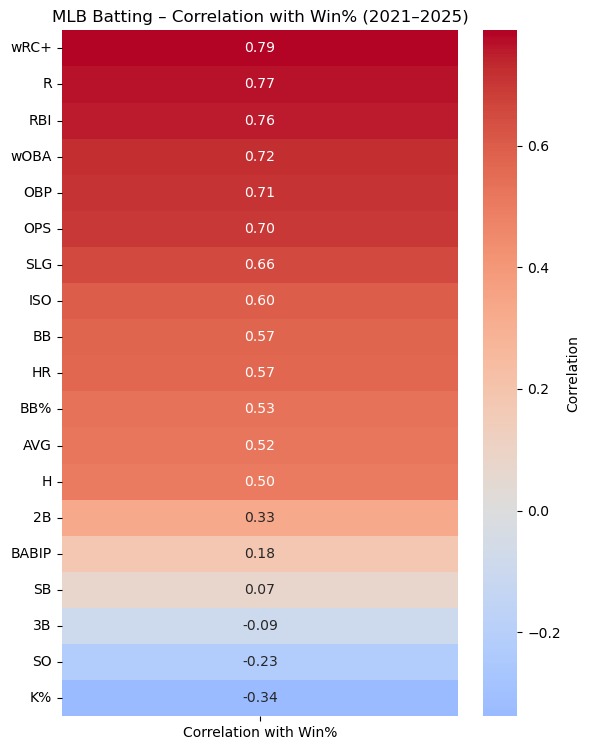

Saved: mlb_batting_heatmap.png


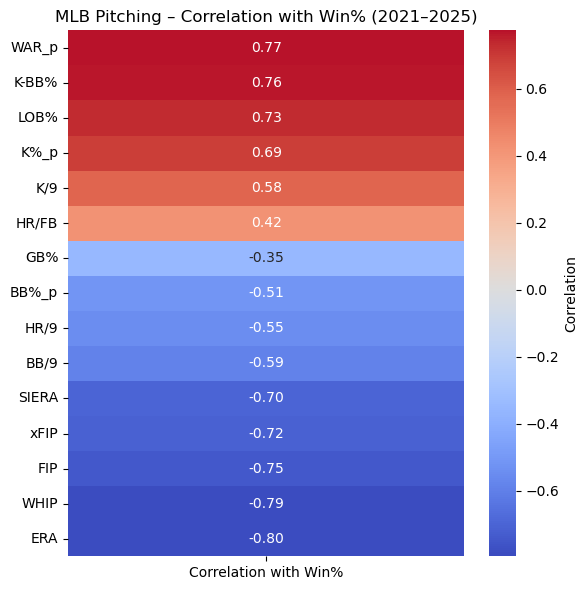

Saved: mlb_pitching_heatmap.png


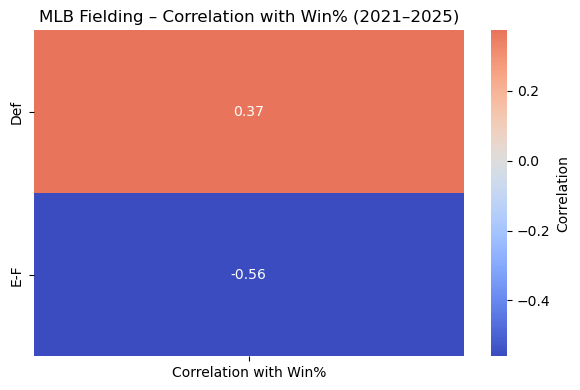

Saved: mlb_fielding_heatmap.png


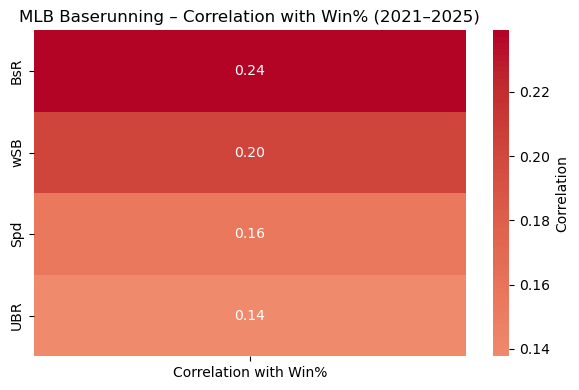

Saved: mlb_baserunning_heatmap.png


In [8]:
# ── Heatmaps: Top positive + top negative correlations per category ────────────
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmap(corr_series, title, filename):
    if corr_series.empty: return
    n = min(len(corr_series), 15)
    top    = corr_series.head(n)
    bottom = corr_series.tail(n).sort_values(ascending=False)
    ordered = pd.concat([top, bottom])
    ordered = ordered[~ordered.index.duplicated()].to_frame(name='Correlation with Win%')
    plt.figure(figsize=(6, max(4, len(ordered) * 0.4)))
    sns.heatmap(ordered, cmap='coolwarm', center=0, annot=True,
                fmt='.2f', cbar_kws={'label': 'Correlation'})
    plt.title(title); plt.ylabel(''); plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show(); print(f'Saved: {filename}')

plot_heatmap(bat_corr,   'MLB Batting – Correlation with Win% (2021–2025)',      'mlb_batting_heatmap.png')
plot_heatmap(pitch_corr, 'MLB Pitching – Correlation with Win% (2021–2025)',     'mlb_pitching_heatmap.png')
if not field_corr.empty:
    plot_heatmap(field_corr, 'MLB Fielding – Correlation with Win% (2021–2025)', 'mlb_fielding_heatmap.png')
if not bsr_corr.empty:
    plot_heatmap(bsr_corr,   'MLB Baserunning – Correlation with Win% (2021–2025)', 'mlb_baserunning_heatmap.png')

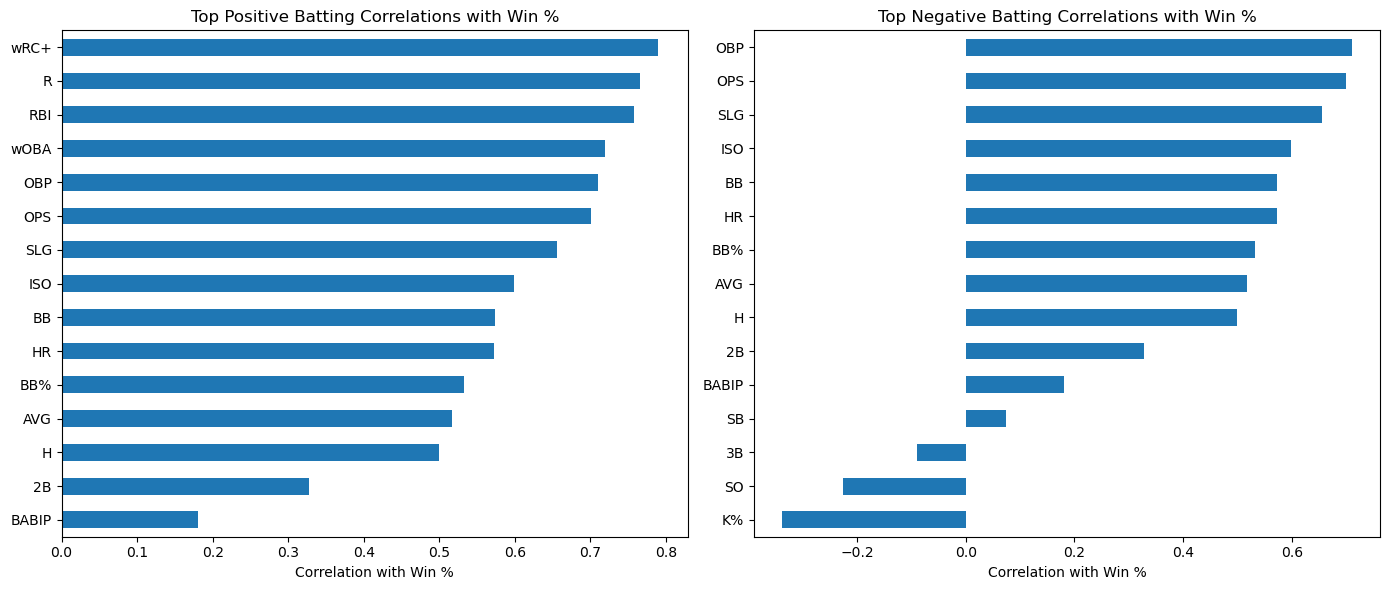

Saved: mlb_batting_bar.png


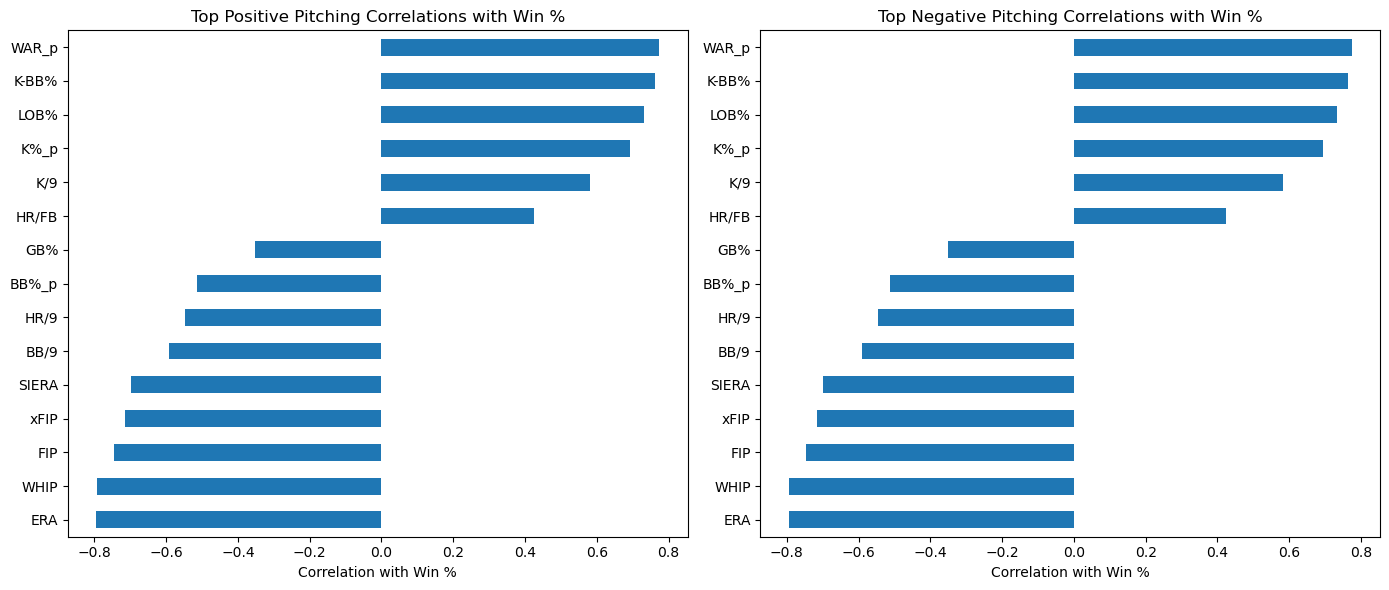

Saved: mlb_pitching_bar.png


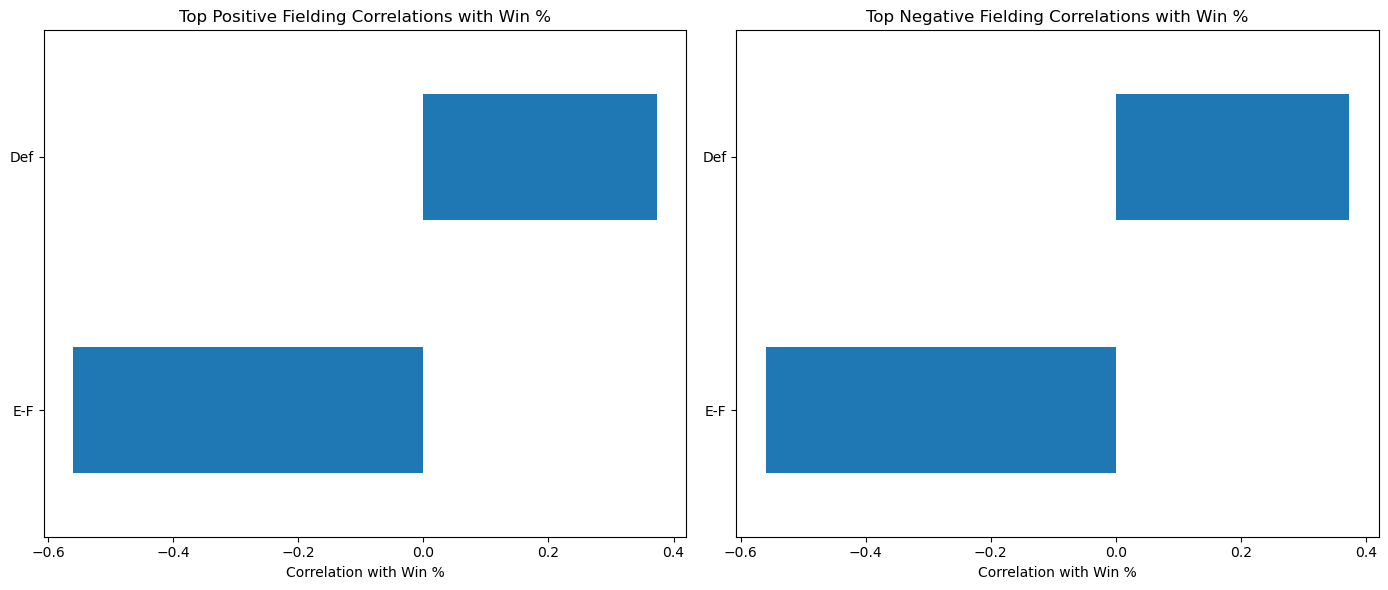

Saved: mlb_fielding_bar.png


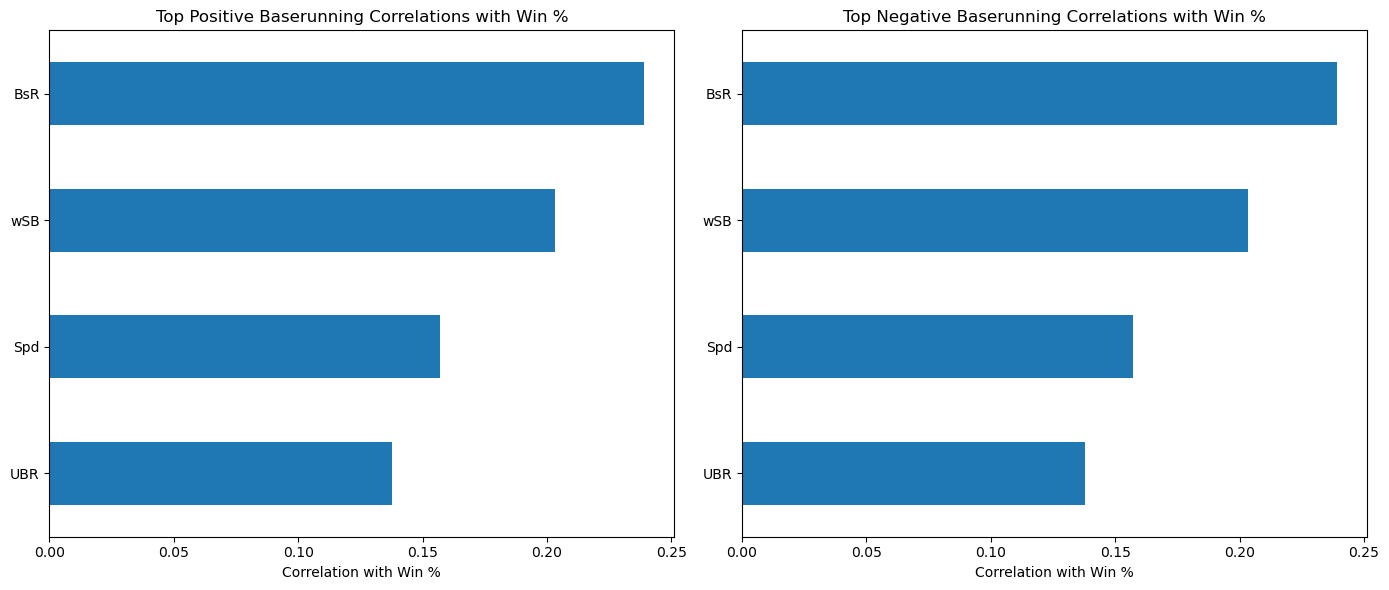

Saved: mlb_baserunning_bar.png


In [9]:
# ── Side-by-side positive / negative bar charts (matching NBA notebook style) ──
def plot_side_by_side(corr_series, label, filename):
    if corr_series.empty: return
    n = min(len(corr_series), 15)
    top    = corr_series.sort_values(ascending=False).head(n)
    bottom = corr_series.sort_values(ascending=True).head(n)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    top.sort_values().plot(kind='barh', ax=axes[0])
    axes[0].set_title(f'Top Positive {label} Correlations with Win %')
    axes[0].set_xlabel('Correlation with Win %')
    bottom.sort_values().plot(kind='barh', ax=axes[1])
    axes[1].set_title(f'Top Negative {label} Correlations with Win %')
    axes[1].set_xlabel('Correlation with Win %')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show(); print(f'Saved: {filename}')

plot_side_by_side(bat_corr,   'Batting',      'mlb_batting_bar.png')
plot_side_by_side(pitch_corr, 'Pitching',     'mlb_pitching_bar.png')
if not field_corr.empty:
    plot_side_by_side(field_corr, 'Fielding',  'mlb_fielding_bar.png')
if not bsr_corr.empty:
    plot_side_by_side(bsr_corr,   'Baserunning', 'mlb_baserunning_bar.png')

In [10]:
# ── Power Rankings: Borda scores combining batting + pitching + fielding ───────
import pandas as pd, numpy as np

# Metrics and direction (True = higher is better)
OFF_METRICS = {c: True  for c in ['wRC+','wOBA','OPS','OBP','SLG','ISO','R','HR'] if c in mlb.columns}
OFF_METRICS.update({c: False for c in ['K%'] if c in mlb.columns})

DEF_METRICS = {c: False for c in ['ERA','FIP','WHIP','BB/9','HR/9'] if c in mlb.columns}
DEF_METRICS.update({c: True  for c in ['K/9','K-BB%'] if c in mlb.columns})

BSR_METRICS = {c: True for c in ['BsR','XBT%','wSB','UBR','Spd'] if c in mlb.columns}

ALL_METRICS = {**OFF_METRICS, **DEF_METRICS, **BSR_METRICS}
print(f'Borda metrics – Off: {len(OFF_METRICS)} | Def: {len(DEF_METRICS)} | BSR: {len(BSR_METRICS)}')

def rank_metric(s, higher_better):
    return s.rank(ascending=not higher_better, method='min')

season_df = mlb.copy()
# FIX 2 (already correct in original): lambda default arg h=hb captures the
# loop variable correctly — preserved as-is.
for col, hb in ALL_METRICS.items():
    season_df[f'rk_{col}'] = season_df.groupby('Season')[col].transform(
        lambda s, h=hb: rank_metric(s, h))

off_rk = [f'rk_{c}' for c in OFF_METRICS if f'rk_{c}' in season_df.columns]
def_rk = [f'rk_{c}' for c in DEF_METRICS if f'rk_{c}' in season_df.columns]
bsr_rk = [f'rk_{c}' for c in BSR_METRICS if f'rk_{c}' in season_df.columns]

season_df['Off_Borda'] = season_df[off_rk].mean(axis=1)
season_df['Def_Borda'] = season_df[def_rk].mean(axis=1) if def_rk else np.nan
season_df['Bsr_Borda'] = season_df[bsr_rk].mean(axis=1) if bsr_rk else np.nan
borda_components = [c for c in ['Off_Borda','Def_Borda','Bsr_Borda'] if not season_df[c].isna().all()]
season_df['Combined_Borda'] = season_df[borda_components].mean(axis=1)
print(f'Borda components used: {borda_components}')

mlb_cross = season_df.groupby('Team').agg(
    Seasons_Played=('Season','nunique'),
    Avg_W_pct=('W_pct','mean'),
    Avg_Combined_Borda=('Combined_Borda','mean'),
    Combined_Borda_StdDev=('Combined_Borda','std'),
).reset_index()

mlb_cross['Avg_W_pct'] *= 100
mlb_cross['Combined_Borda_StdDev'] = mlb_cross['Combined_Borda_StdDev'].fillna(0)
mlb_cross['Overall_Combined_Rank'] = mlb_cross['Avg_Combined_Borda'].rank(
    ascending=True, method='min').astype(int)
mlb_cross['Consistency_Rank'] = mlb_cross['Combined_Borda_StdDev'].replace(0, np.nan).rank(
    ascending=True, method='min', na_option='bottom').astype(int)

df = mlb_cross.copy()
print(f'{len(df)} teams in rankings')
df.sort_values('Avg_W_pct', ascending=False).head(10)

Borda metrics – Off: 9 | Def: 7 | BSR: 4
Borda components used: ['Off_Borda', 'Def_Borda', 'Bsr_Borda']
30 teams in rankings


,Team,Seasons_Played,Avg_W_pct,Avg_Combined_Borda,Combined_Borda_StdDev,Overall_Combined_Rank,Consistency_Rank
13,Los Angeles Dodgers,5,62.716049,7.608730,3.041956,1,8
10,Houston Astros,5,57.530864,13.308730,2.975173,9,7
15,Milwaukee Brewers,5,57.160494,11.171429,1.855391,4,1
18,New York Yankees,5,56.913580,13.552646,3.593210,10,13
1,Atlanta Braves,5,56.610689,11.625661,4.837646,5,27
20,Philadelphia Phillies,5,55.555556,8.524074,2.282900,2,2
24,Seattle Mariners,5,54.691358,14.162963,4.256612,12,18
26,Tampa Bay Rays,5,54.567901,10.485450,4.478089,3,21
28,Toronto Blue Jays,5,54.320988,14.686508,4.545310,15,23
22,San Diego Padres,5,53.456790,12.680688,2.920916,6,6


In [11]:
# ── Fetch ESPN team logos ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt, numpy as np
from matplotlib.widgets import Slider
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import requests
from io import BytesIO

n_teams     = len(df)
min_borda   = df['Avg_Combined_Borda'].min()
max_borda   = df['Avg_Combined_Borda'].max()
max_consist = df['Consistency_Rank'].max()

abbr_map = {
    'Arizona Diamondbacks':'ari','Atlanta Braves':'atl','Baltimore Orioles':'bal',
    'Boston Red Sox':'bos','Chicago Cubs':'chc','Chicago White Sox':'chw',
    'Cincinnati Reds':'cin','Cleveland Guardians':'cle','Colorado Rockies':'col',
    'Detroit Tigers':'det','Houston Astros':'hou','Kansas City Royals':'kc',
    'Los Angeles Angels':'laa','Los Angeles Dodgers':'lad','Miami Marlins':'mia',
    'Milwaukee Brewers':'mil','Minnesota Twins':'min','New York Mets':'nym',
    'New York Yankees':'nyy','Oakland Athletics':'oak','Philadelphia Phillies':'phi',
    'Pittsburgh Pirates':'pit','San Diego Padres':'sd','San Francisco Giants':'sf',
    'Seattle Mariners':'sea','St. Louis Cardinals':'stl','Tampa Bay Rays':'tb',
    'Texas Rangers':'tex','Toronto Blue Jays':'tor','Washington Nationals':'wsh',
}

missing = sorted(set(df['Team']) - set(abbr_map.keys()))
if missing: print('Missing from abbr_map:', missing)

def fetch_logo(abbr, size=28):
    try:
        url = f'https://a.espncdn.com/combiner/i?img=/i/teamlogos/mlb/500/{abbr}.png&h=80&w=80'
        return np.array(
            Image.open(BytesIO(requests.get(url, timeout=5).content))
            .convert('RGBA').resize((size, size), Image.LANCZOS))
    except:
        return None

print('Fetching logos...')
logos = {abbr: fetch_logo(abbr) for abbr in abbr_map.values()}
print('Done.')

Fetching logos...
Done.


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

0

0

0

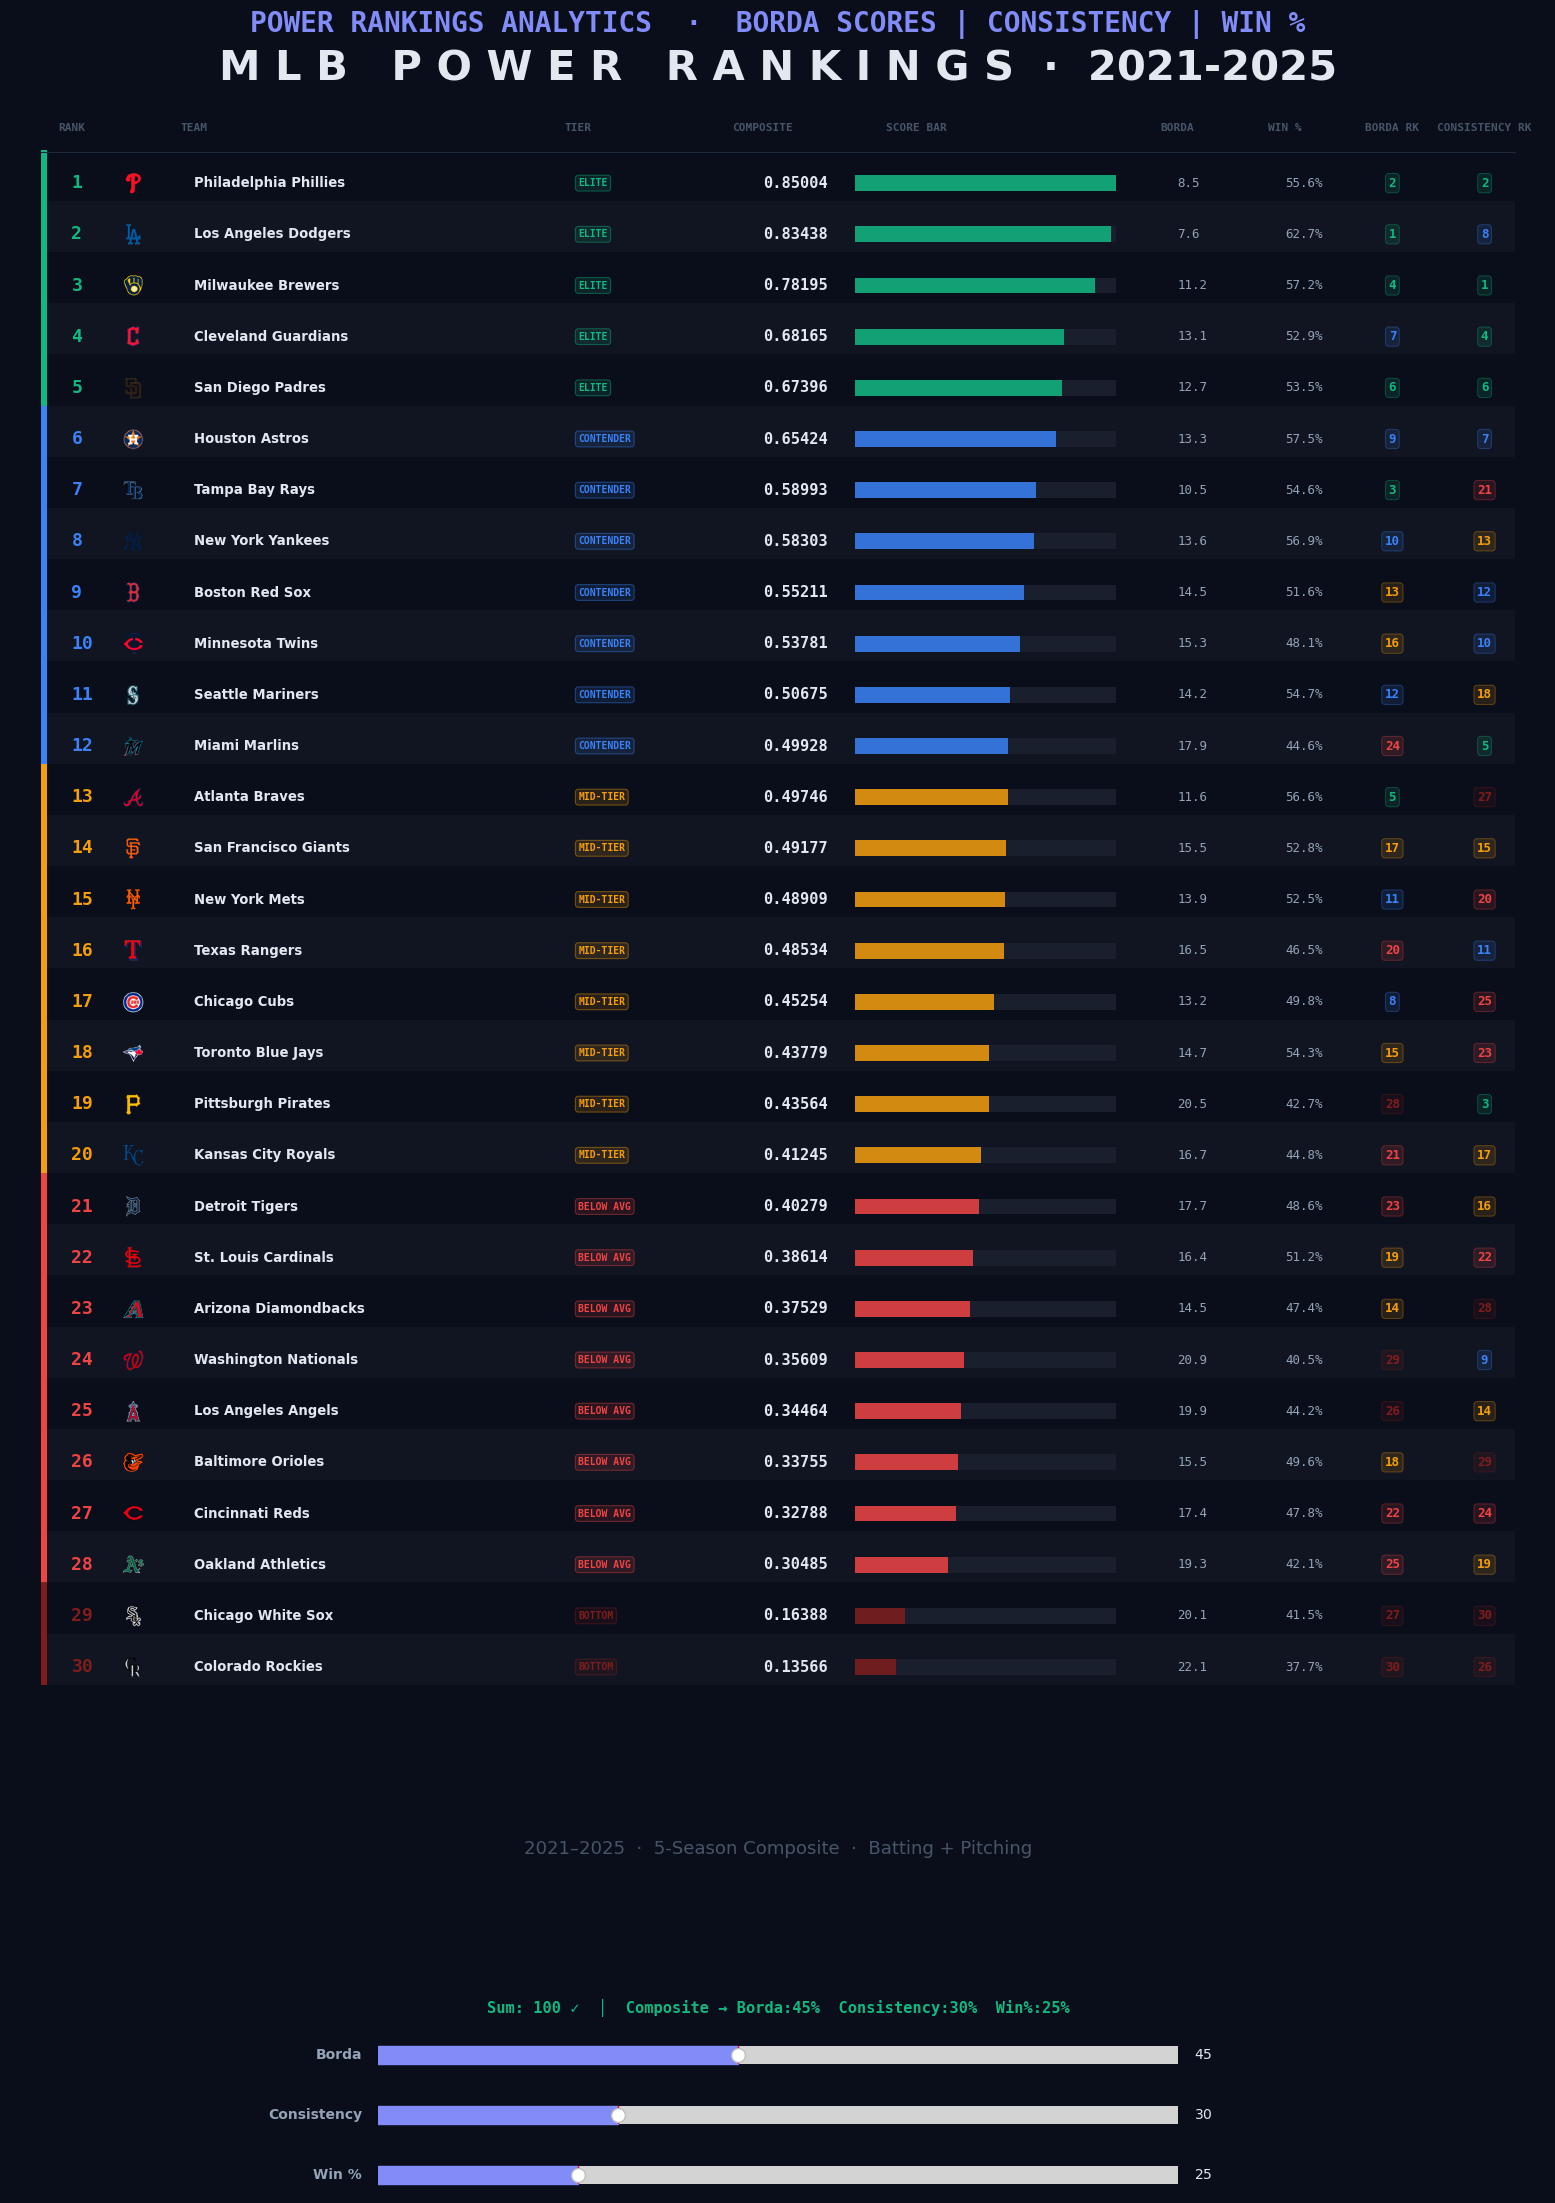

In [12]:
# ── Power Rankings visualization with interactive weight sliders ───────────────
import matplotlib.pyplot as plt, numpy as np

def compute_composite(row, weights):
    nb = 1 - (row['Avg_Combined_Borda'] - min_borda) / max(max_borda - min_borda, 1e-9)
    nc = 1 - (row['Consistency_Rank'] - 1) / max(max_consist - 1, 1)
    nw = row['Avg_W_pct'] / 100
    return round(nb * weights['borda'] + nc * weights['consistency'] + nw * weights['win_pct'], 5)

def get_tier(rank):
    if rank <= 5:  return ('ELITE',     '#10b981')
    if rank <= 12: return ('CONTENDER', '#3b82f6')
    if rank <= 20: return ('MID-TIER',  '#f59e0b')
    if rank <= 28: return ('BELOW AVG', '#ef4444')
    return                ('BOTTOM',    '#7f1d1d')

fig = plt.figure(figsize=(16, 24))
fig.patch.set_facecolor('#0a0e1a')
ax  = fig.add_axes([0.02, 0.11, 0.96, 0.82])
ax.set_facecolor('#0a0e1a'); ax.axis('off')

sc = '#1e293b'; ac = '#818cf8'
ax_b = fig.add_axes([0.25, 0.095, 0.50, 0.015], facecolor=sc)
ax_c = fig.add_axes([0.25, 0.070, 0.50, 0.015], facecolor=sc)
ax_w = fig.add_axes([0.25, 0.045, 0.50, 0.015], facecolor=sc)
s_borda   = Slider(ax_b, 'Borda',       0, 100, valinit=45, valstep=1, color=ac)
s_consist = Slider(ax_c, 'Consistency', 0, 100, valinit=30, valstep=1, color=ac)
s_wpct    = Slider(ax_w, 'Win %',       0, 100, valinit=25, valstep=1, color=ac)
for s in [s_borda, s_consist, s_wpct]:
    s.label.set_color('#94a3b8'); s.label.set_fontsize(10); s.label.set_fontweight('bold')
    s.valtext.set_color('#e2e8f0'); s.valtext.set_fontsize(10)

wt = fig.text(0.50, 0.120, '', ha='center', fontsize=11, fontweight='bold', fontfamily='monospace')

def update(val=None):
    ax.clear(); ax.set_facecolor('#0a0e1a'); ax.axis('off'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    rb, rc, rw = s_borda.val, s_consist.val, s_wpct.val
    tot = rb + rc + rw
    if tot == 0: weights = {'borda': 1/3, 'consistency': 1/3, 'win_pct': 1/3}; tot = 100
    else:        weights = {'borda': rb/tot, 'consistency': rc/tot, 'win_pct': rw/tot}
    wt.set_text(
        f"Sum: {int(tot)} {'✓' if abs(tot-100)<1 else '!'}  │  "
        f"Composite → Borda:{weights['borda']:.0%}  Consistency:{weights['consistency']:.0%}  Win%:{weights['win_pct']:.0%}")
    wt.set_color('#10b981' if abs(tot-100) < 1 else '#f59e0b')
    df['Composite'] = df.apply(compute_composite, axis=1, weights=weights)
    ranked = df.sort_values('Composite', ascending=False).reset_index(drop=True)
    ranked['Power_Rank'] = range(1, n_teams + 1)
    mc = ranked['Composite'].max()
    rh = 0.026; hy = 0.97; sy = hy - 0.028
    ax.text(0.5, 1.03, 'POWER RANKINGS ANALYTICS  ·  BORDA SCORES | CONSISTENCY | WIN %',
            transform=ax.transAxes, ha='center', va='top', fontsize=20,
            fontweight='bold', color='#818cf8', fontfamily='monospace')
    ax.text(0.5, 1.01, 'M L B   P O W E R   R A N K I N G S  ·  2021-2025',
            transform=ax.transAxes, ha='center', va='top', fontsize=30,
            fontweight='bold', color='#e2e8f0')
    ax.text(0.5, 0.100, '2021–2025  ·  5-Season Composite  ·  Batting + Pitching',
            transform=ax.transAxes, ha='center', va='top', fontsize=13, color='#475569')
    cols = {
        'rank': 0.04, 'logo': 0.08, 'team': 0.12, 'tier': 0.37,
        'composite': 0.49, 'bar_start': 0.55, 'bar_end': 0.72,
        'borda': 0.76, 'wpct': 0.83, 'borda_rk': 0.90, 'consist_rk': 0.96
    }
    for x, lbl in [
        (cols['rank'], 'RANK'), (cols['team'], 'TEAM'), (cols['tier'], 'TIER'),
        (cols['composite'], 'COMPOSITE'), (cols['bar_start']+0.04, 'SCORE BAR'),
        (cols['borda'], 'BORDA'), (cols['wpct'], 'WIN %'),
        (cols['borda_rk'], 'BORDA RK'), (cols['consist_rk'], 'CONSISTENCY RK')
    ]:
        ax.text(x, hy, lbl, ha='center', transform=ax.transAxes, fontsize=8,
                fontweight='bold', color='#475569', fontfamily='monospace', va='center')
    ax.plot([0.02, 0.98], [hy-0.012, hy-0.012], transform=ax.transAxes, color='#1e293b', linewidth=0.8)
    for i, (_, row) in enumerate(ranked.iterrows()):
        yp = sy - i * rh
        tm = row['Team']
        # FIX 2: Don't fall back to a default abbreviation — skip logo if team is missing.
        abbr = abbr_map.get(tm)
        tl, tc = get_tier(row['Power_Rank'])
        if i % 2 == 1:
            ax.add_patch(plt.Rectangle((0.02, yp-rh/2+0.004), 0.96, rh,
                         transform=ax.transAxes, facecolor='#ffffff08', edgecolor='none', zorder=0))
        ax.add_patch(plt.Rectangle((0.02, yp-rh/2+0.004), 0.004, rh,
                     transform=ax.transAxes, facecolor=tc, edgecolor='none', zorder=1))
        ax.text(cols['rank'], yp, str(row['Power_Rank']), transform=ax.transAxes,
                fontsize=13, fontweight='bold', color=tc, va='center', fontfamily='monospace')
        # Only render logo if abbreviation exists and logo loaded successfully
        if abbr and logos.get(abbr) is not None:
            ax.add_artist(AnnotationBbox(
                OffsetImage(logos[abbr], zoom=0.55), (cols['logo'], yp),
                xycoords='axes fraction', frameon=False, box_alignment=(0.5, 0.5)))
        ax.text(cols['team'], yp, tm, transform=ax.transAxes,
                fontsize=9.5, fontweight='bold', color='#e2e8f0', va='center')
        ax.text(cols['tier'], yp, tl, transform=ax.transAxes, fontsize=7,
                fontweight='bold', color=tc, va='center', fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=tc+'22', edgecolor=tc+'66', linewidth=0.8))
        ax.text(cols['composite'], yp, f"{row['Composite']}", transform=ax.transAxes,
                fontsize=11, fontweight='bold', color='#e2e8f0', va='center', fontfamily='monospace')
        bw = (cols['bar_end'] - cols['bar_start']) * (row['Composite'] / mc) if mc > 0 else 0
        ax.add_patch(plt.Rectangle((cols['bar_start'], yp-0.004),
                     cols['bar_end']-cols['bar_start'], 0.008,
                     transform=ax.transAxes, facecolor='#1a1f2e', edgecolor='none', zorder=1))
        ax.add_patch(plt.Rectangle((cols['bar_start'], yp-0.004), bw, 0.008,
                     transform=ax.transAxes, facecolor=tc, edgecolor='none', zorder=2, alpha=0.85))
        ax.text(cols['borda'], yp, f"{row['Avg_Combined_Borda']:.1f}",
                transform=ax.transAxes, fontsize=9, color='#94a3b8', va='center', fontfamily='monospace')
        ax.text(cols['wpct'], yp, f"{row['Avg_W_pct']:.1f}%",
                transform=ax.transAxes, fontsize=9, color='#94a3b8', va='center', fontfamily='monospace')
        for cx, v in [(cols['borda_rk'], row['Overall_Combined_Rank']),
                      (cols['consist_rk'], row['Consistency_Rank'])]:
            p = (n_teams - v) / (n_teams - 1)
            bc = ('#10b981' if p > 0.8 else '#3b82f6' if p > 0.6
                  else '#f59e0b' if p > 0.35 else '#ef4444' if p > 0.15 else '#7f1d1d')
            ax.text(cx, yp, str(int(v)), transform=ax.transAxes, fontsize=9,
                    fontweight='bold', color=bc, va='center', ha='center', fontfamily='monospace',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor=bc+'22', edgecolor=bc+'55', linewidth=0.7))
    fig.canvas.draw_idle()

s_borda.on_changed(update); s_consist.on_changed(update); s_wpct.on_changed(update)
update()
plt.savefig('mlb_power_rankings.png', dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()